In [1]:
# import libraries 
import os,warnings,cartopy
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.path as mpath
import matplotlib.dates as mdates
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from cartopy.util import add_cyclic_point

import xarray as xr
import pandas as pd
from datetime import datetime
from scipy import stats, signal

from matplotlib.ticker import MultipleLocator

warnings.filterwarnings('ignore') # Turns off warnings


# Read in and Prepare Data

In [27]:
ds = xr.open_dataset('storm_rainfall.nc')

lat_mask = (ds.lat >= 25) & (ds.lat <= 49)
lon_mask = (ds.lon >= -105) & (ds.lon <= -67)

rain = ds.sel(lat=lat_mask, lon=lon_mask)
rain = rain.where(rain != 0)

del ds

In [28]:
rain_rate = (rain.rain / rain.hits).where(rain.hits > 0)

del rain
rain_rate

<xarray.DataArray (storm: 53, lat: 576, lon: 912)> Size: 223MB
array([[[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]],

       [[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]],

       [[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
...
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]],

       [[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]],

       [[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]]], shape=(53, 576, 912))
Coordinates:
  * storm    (storm) <U9 2kB 'Milton' 'Helene' 'Francine' ... 'Fran' 'Bertha'
    year     (storm) int64 424B 2024 2024 2024 2024 2024 ... 1998 1997 1996 1996
    cat      (storm) float64 424B 3.0 4.0 2.0 1.0 1.0 ... 1.0 2.0 1.0 3.0 2.0
  * lat      (lat) float64 5kB 25.04 25.08 25.12 25.17 ... 48.92 48.96 49.0
  * lon      (lon) float64 7kB -105.0 -105.0 -104.9 ... -67.12 -67.08 -67.04

In [29]:
rain_rates = rain_rate.values.flatten()
rain_rates = rain_rates[~np.isnan(rain_rates)]
rain_rates = rain_rates[~(rain_rates==0)]

In [30]:
shape, loc, scale = stats.gamma.fit(rain_rates, floc=0)
x = np.arange(loc, np.max(rain_rate), 5)
pdf = stats.gamma.pdf(x, a=shape, loc=loc, scale=scale)

In [31]:
rain_early = rain_rate.sel(storm=rain_rate.year <= 2010)
rain_late = rain_rate.sel(storm=rain_rate.year > 2010)

In [32]:
rain_rates_early = rain_early.values.flatten()
rain_rates_early = rain_rates_early[~np.isnan(rain_rates_early)]
rain_rates_early = rain_rates_early[~(rain_rates_early==0)]

shape_early, loc_early, scale_early = stats.gamma.fit(rain_rates_early, floc=0)
x_early = np.arange(loc, np.max(rain_rates_early), 5)
pdf_early = stats.gamma.pdf(x_early, a=shape_early, loc=loc_early, scale=scale_early)

In [33]:
rain_rates_late = rain_late.values.flatten()
rain_rates_late = rain_rates_late[~np.isnan(rain_rates_late)]
rain_rates_late = rain_rates_late[~(rain_rates_late==0)]

shape_l, loc_l, scale_l = stats.gamma.fit(rain_rates_late, floc=0)
x_late = np.arange(loc, np.max(rain_rates_late), 5)
pdf_late = stats.gamma.pdf(x_late, a=shape_l, loc=loc_l, scale=scale_l)

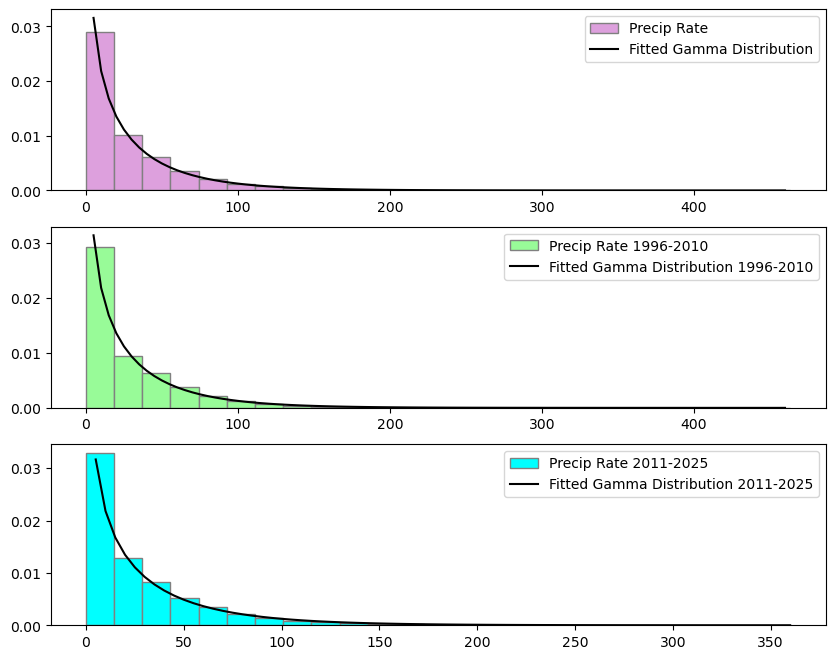

In [39]:
fig = plt.figure(figsize=(10,8))
ax = fig.add_subplot(311)

# add histogram of actual values (density=True allows for probability density)
ax.hist(rain_rates, bins=25, density=True, color='plum', edgecolor='gray', label='Precip Rate')
ax.plot(x, pdf, color='black', label='Fitted Gamma Distribution')
ax.legend()

ax = fig.add_subplot(312)
ax.hist(rain_rates_early, bins=25, density=True, color='palegreen', edgecolor='gray', label='Precip Rate 1996-2010')
ax.plot(x_early, pdf_early, color='black', label='Fitted Gamma Distribution 1996-2010')
ax.legend()

ax = fig.add_subplot(313)
ax.hist(rain_rates_late, bins=25, density=True, color='cyan', edgecolor='gray', label='Precip Rate 2011-2025')
ax.plot(x_late, pdf_late, color='black', label='Fitted Gamma Distribution 2011-2025')
ax.legend()

In [22]:
rain_minor = rain_late.sel(storm=rain_late.cat <= 2)
rain_major = rain_late.sel(storm=rain_late.cat > 2)

In [23]:
rain_rates_major = rain_major.values.flatten()
rain_rates_major = rain_rates_major[~np.isnan(rain_rates_major)]
rain_rates_major= rain_rates_major[~(rain_rates_major==0)]

shape_major, loc_major, scale_major = stats.gamma.fit(rain_rates_major, floc=0)
x_major = np.arange(loc, np.max(rain_rates_major), 5)
pdf_major = stats.gamma.pdf(x_major, a=shape_major, loc=loc_major, scale=scale_major)

In [24]:
rain_rates_minor = rain_minor.values.flatten()
rain_rates_minor = rain_rates_minor[~np.isnan(rain_rates_minor)]
rain_rates_minor= rain_rates_minor[~(rain_rates_minor==0)]

shape_minor, loc_minor, scale_minor = stats.gamma.fit(rain_rates_minor, floc=0)
x_minor = np.arange(loc, np.max(rain_rates_minor), 5)
pdf_minor = stats.gamma.pdf(x_minor, a=shape_minor, loc=loc_minor, scale=scale_minor)

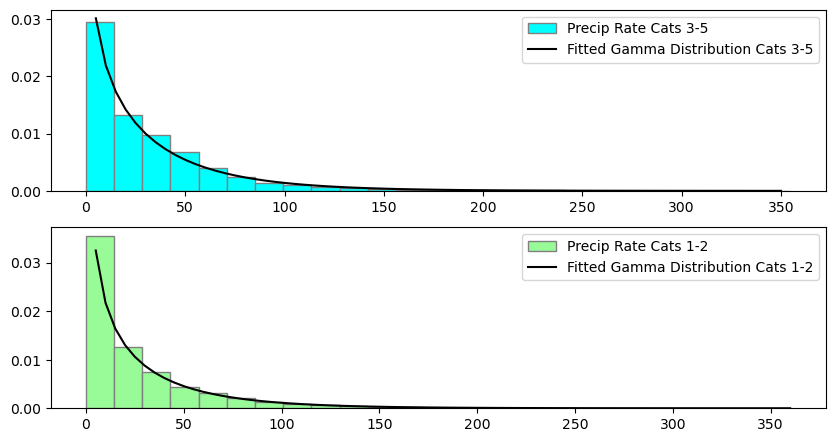

In [25]:
fig = plt.figure(figsize=(10,8))
ax = fig.add_subplot(311)

ax.hist(rain_rates_major, bins=25, density=True, color='cyan', edgecolor='gray', label='Precip Rate Cats 3-5')
ax.plot(x_major, pdf_major, color='black', label='Fitted Gamma Distribution Cats 3-5')
ax.legend()

ax = fig.add_subplot(312)
ax.hist(rain_rates_minor, bins=25, density=True, color='palegreen', edgecolor='gray', label='Precip Rate Cats 1-2')
ax.plot(x_minor, pdf_minor, color='black', label='Fitted Gamma Distribution Cats 1-2')
ax.legend()



In [26]:
rain_major

<xarray.DataArray (storm: 9, lat: 576, lon: 912)> Size: 38MB
array([[[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]],

       [[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]],

       [[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
...
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]],

       [[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]],

       [[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]]], shape=(9, 576, 912))
Coordinates:
  * storm    (storm) <U9 324B 'Helene' 'Idalia' 'Ian' ... 'Irma' 'Harvey'
    year     (storm) int64 72B 2024 2023 2022 2021 2020 2020 2018 2017 2017
    cat      (storm) float64 72B 4.0 3.0 4.0 4.0 3.0 4.0 5.0 4.0 4.0
  * lat      (lat) float64 5kB 25.04 25.08 25.12 25.17 ... 48.92 48.96 49.0
  * lon      (lon) float64 7kB -105.0 -105.0 -104.9 ... -67.12 -67.08 -67.04

In [ ]:
gg